Confusion Matrix:
[[66 11]
 [12 95]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.85        77
           1       0.90      0.89      0.89       107

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184



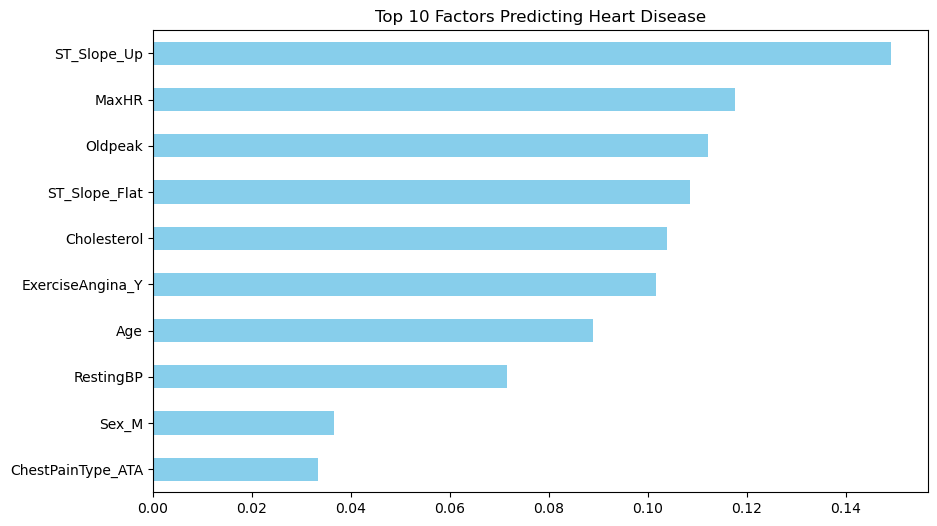

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load Data
df = pd.read_csv('heart.csv')

# 2. Preprocessing: Convert text (Categorical) to numbers
# This creates 'dummy variables' so the math model can understand text categories
df_encoded = pd.get_dummies(df, drop_first=True)

# 3. Split data into Features (X) and Target (y)
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# 4. Split into Training set (80%) and Test set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train the Model (Random Forest)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. Make Predictions
predictions = model.predict(X_test)

# 7. Print Results
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))
print("\nClassification Report:")
print(classification_report(y_test, predictions))

# 8. Feature Importance Plot
importances = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(10,6))
importances.nlargest(10).sort_values().plot(kind='barh', color='skyblue')
plt.title('Top 10 Factors Predicting Heart Disease')
plt.show()

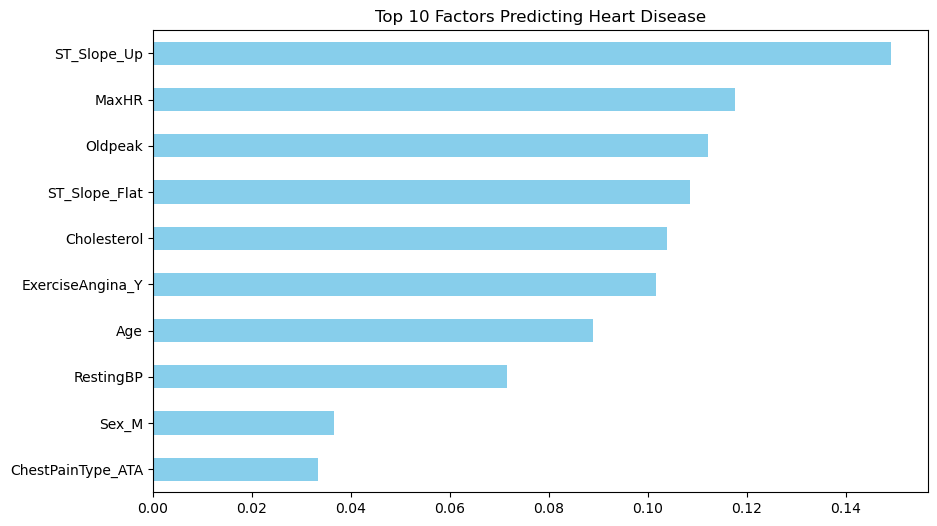

In [2]:
# Create a plot of Feature Importances
importances = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(10,6))
importances.nlargest(10).sort_values().plot(kind='barh', color='skyblue')
plt.title('Top 10 Factors Predicting Heart Disease')
plt.show()